In [1]:
import sys; sys.path.insert(0, ".")

import pandas as pd

from constants import ret_path
from port_sort import (
    build_sml_panel,
    get_sml_panel_extra_char,
    plot_sml_conditional,
    run_sml_fm_by_quintiles,
)


In [2]:
# Parameters
# cond_char: beta_dimson_21d, betabab_1260d, betadown_252d, ivol_capm_21d, ivol_capm_252d,
#            ivol_ff3_21d, ivol_hxz4_21d, rmax1_21d, rmax5_21d, rvol_21d, turnover_126d, coskew_21d,
#            iskew_capm_21d, iskew_ff3_21d, iskew_hxz4_21d, ret_1_0, rmax5_rvol_21d, rskew_21d,
#            prc_highprc_252d, resff3_6_1, resff3_12_1, ret_3_1, ret_6_1, ret_9_1, ret_12_1, seas_1_1na
beta_col = "Beta252d"
cond_char = "ivol_capm_21d"
# Set to True only if you want to sort on |char| rather than char itself.
rank_by_abs = False
eqw = False
non_special_only = False

k_groups = 10
low = 0.2
high = 0.8
lags = 10


In [3]:
# Build the original SML sample and add the extra-char ranking.
sml_panel = build_sml_panel(beta_col=beta_col)
ff6_daily = pd.read_csv(ret_path + "ff6_daily_returns.csv")

sml_panel_extra_char = get_sml_panel_extra_char(
    sml_panel,
    cond_char,
    non_special_only=non_special_only,
    rank_by_abs=rank_by_abs,
)


Original build_sml_panel sample | months: 240, permnos: 7,075, rows: 12,095,642
Extra-char sample | months: 239, permnos: 7,066, rows: 12,035,560
JKP lagged-char window | months: 200412 to 202512
Current-char analysis window | months: 200412 to 202511
Missing before impute: 1,320,976 (10.98%)
Missing after impute:  1,316,128 (10.94%)


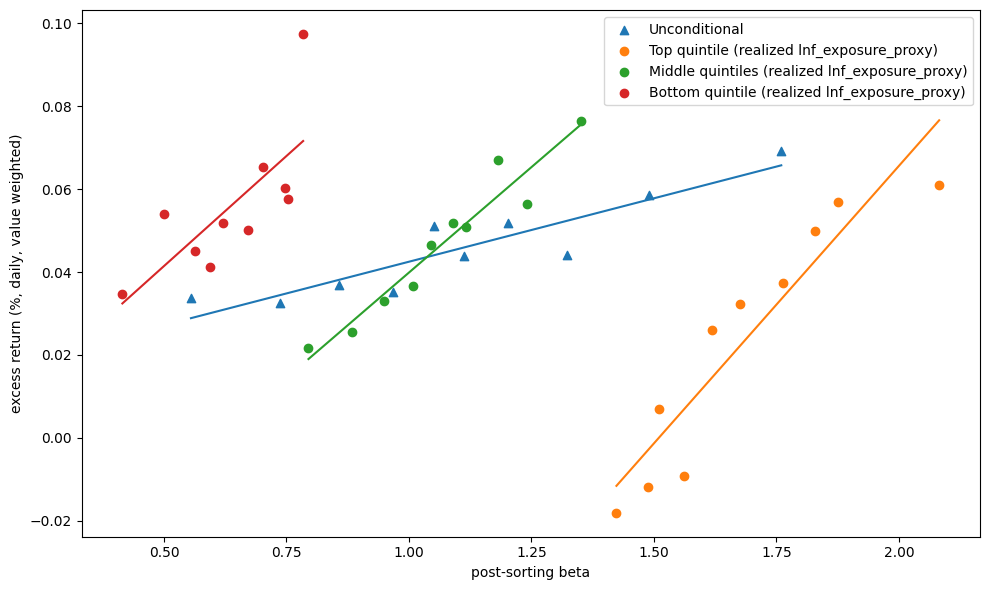

In [4]:
# Replication check using the original lnf_exposure_proxy ranking on the same sample period.
plot_sml_conditional(
    sml_panel_extra_char,
    ff6_daily,
    eqw=eqw,
    k_groups=k_groups,
    beta_col="beta_sort",
    low=low,
    high=high,
    quantile_col="news_exposure_quantile",
    condition_label="realized lnf_exposure_proxy",
    save_filename=None,
)


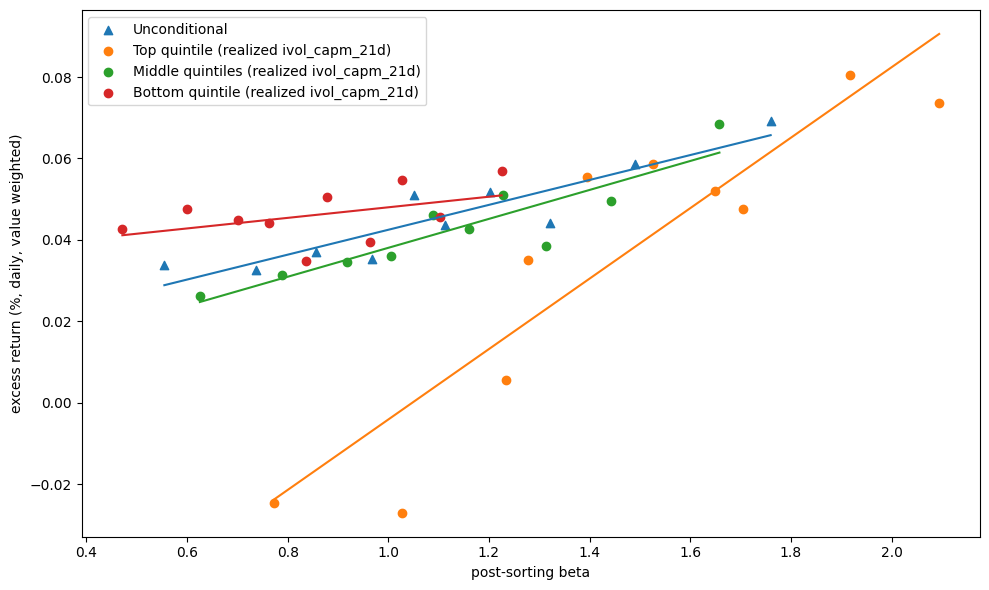

In [5]:
# Conditional SML using the selected current-month characteristic.
# Save the PDF only for the paper figure (fig:sml_vw_cond_ivol -> sml_vw_cond_ivol21d.pdf).
save_filename = "sml_vw_cond_ivol21d.pdf" if cond_char == "ivol_capm_21d" else None
plot_sml_conditional(
    sml_panel_extra_char,
    ff6_daily,
    eqw=eqw,
    k_groups=k_groups,
    beta_col="beta_sort",
    low=low,
    high=high,
    quantile_col="char_quantile",
    condition_label="realized "+cond_char,
    save_filename=save_filename,
)


In [6]:
# Fama-MacBeth regressions using the selected current-month characteristic.
fm_sml_alt = run_sml_fm_by_quintiles(
    sml_panel_extra_char,
    ff6_daily=ff6_daily,
    eqw=eqw,
    beta_col="beta_sort",
    k_groups=k_groups,
    lags=lags,
    low=low,
    high=high,
    quantile_col="char_quantile",
    condition_label=cond_char,
)


********************full-sample: value-weight********************
[ret_ex]  Mean(Intercept) = 0.017, t(NW) = 1.20
[ret_ex]  Mean(beta)       = 0.024, t(NW) = 1.29
[ret_ex]  Avg adj-R^2     = 0.4616
********************top ivol_capm_21d quintile: value-weight********************
[ret_ex]  Mean(Intercept) = -0.055, t(NW) = -1.81
[ret_ex]  Mean(beta)       = 0.063, t(NW) = 2.66
[ret_ex]  Avg adj-R^2     = 0.1710
********************middle ivol_capm_21d quintiles: value-weight********************
[ret_ex]  Mean(Intercept) = 0.012, t(NW) = 0.75
[ret_ex]  Mean(beta)       = 0.027, t(NW) = 1.52
[ret_ex]  Avg adj-R^2     = 0.3759
********************bottom ivol_capm_21d quintile: value-weight********************
[ret_ex]  Mean(Intercept) = 0.035, t(NW) = 2.91
[ret_ex]  Mean(beta)       = 0.011, t(NW) = 0.64
[ret_ex]  Avg adj-R^2     = 0.3156
